## Abstract for Presentation

This notebook benchmarks sustainability classification models on the updated processed dataset and compares performance with efficiency constraints.
It includes train/test evaluation, training-time and inference-time computation, SHAP-based explainability, and deployment-ready artifact export.
Additional visual diagnostics include train-vs-validation learning curves and spiral-net (radar) accuracy-oriented comparison for individual models.

# 03 — Sustainability Classification

**Owner:** Shravya

---

### Purpose
- Train a classification model (XGBoost) to classify sustainability levels
- Evaluate with accuracy, precision, recall, F1-score
- Generate SHAP explanations
- Save model and metrics

### Input
| File | Path |
|------|------|
| Processed dataset | `data/processed/final_dataset.csv` |

### Outputs
| File | Path | Description |
|------|------|-------------|
| Trained model | `models/sustainability_model.pkl` | XGBoost classifier |
| Metrics | `results/sustainability_metrics.csv` | Accuracy, F1, Precision, Recall |

### For Colab Users
```python
# After training, save and download:
import joblib
joblib.dump(model, "sustainability_model.pkl")
# Then upload .pkl to models/ and .csv to results/ on GitHub
```

In [ ]:
# ============================================================
# IMPORTS + RUNTIME SETTINGS (faster + quieter on Windows)
# ============================================================
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import warnings
warnings.filterwarnings("ignore", message=".*add_reader family of methods required for zmq.*")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from xgboost import XGBClassifier
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# Lighter training config to avoid notebook stalls during presentation reruns.
FAST_EPOCHS = {"MLP": 12, "1D CNN": 10, "GRU": 8, "LSTM": 8, "CNN-LSTM": 8}
BATCH_SIZE = 64
EARLY_STOP = EarlyStopping(monitor="val_accuracy", mode="max", patience=2, restore_best_weights=True)

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
# If running in Colab, upload final_dataset.csv or mount drive
# DATA_PATH = "final_dataset.csv"          # Colab
DATA_PATH = os.path.join("..", "data", "processed", "final_dataset.csv")  # Local

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11657, 22)


,country,year,production,temperature_celsius,precip_mm,humidity,water_Salinity (ppt),water_pH,water_SecchiDepth (m),water_WaterDepth (m),...,genomic_GC_Content_global_mean,genomic_AT_Content_global_mean,genomic_Sequence_Length_global_mean,genomic_Num_A_global_mean,genomic_Num_T_global_mean,genomic_Num_C_global_mean,genomic_Num_G_global_mean,genomic_kmer_3_freq_global_mean,genomic_Mutation_Flag_global_mean,genomic_Disease_Risk_global_mode
0,Afghanistan,1969,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
1,Afghanistan,1970,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
2,Afghanistan,1971,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
3,Afghanistan,1972,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
4,Afghanistan,1973,60.0,0.0,0.0,0.0,0.228486,0.105062,-0.082553,-0.014603,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High


In [3]:
# ============================================================
# SUSTAINABILITY SCORE (water quality + climate)
# ============================================================
# STEP 1: Select features (ignore genomic + production)
cols = [
    "water_pH",
    "water_Salinity (ppt)",
    "water_SecchiDepth (m)",
    "water_WaterTemp (C)",
    "water_AirTemp (C)",
    "temperature_celsius",
    "precip_mm",
    "humidity",
]
df_feat = df[cols].copy()

# STEP 2: Clean column names
df_feat = df_feat.rename(
    columns={
        "water_Salinity (ppt)": "salinity",
        "water_pH": "ph",
        "water_SecchiDepth (m)": "secchi_depth",
        "water_WaterTemp (C)": "water_temp",
        "water_AirTemp (C)": "air_temp",
    }
)

# STEP 3: Handle missing values (mean)
for c in df_feat.columns:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")
    df_feat[c] = df_feat[c].fillna(df_feat[c].mean())

if df_feat.isna().any().any():
    raise ValueError("NaN values remain after mean imputation.")

# STEP 4: Normalize features (min-max)
ranges = {}
for c in df_feat.columns:
    min_val = df_feat[c].min()
    max_val = df_feat[c].max()
    if min_val == max_val:
        df_feat[c] = 0.5
        ranges[c] = 1.0
    else:
        df_feat[c] = (df_feat[c] - min_val) / (max_val - min_val)
        ranges[c] = max_val - min_val

# STEP 5: Convert to suitability scores (0-1)
ph_range = ranges["ph"]
salinity_range = ranges["salinity"]
water_temp_range = ranges["water_temp"]
air_temp_range = ranges["air_temp"]
climate_temp_range = ranges["temperature_celsius"]
rainfall_range = ranges["precip_mm"]
humidity_range = ranges["humidity"]

optimal_salinity = df["water_Salinity (ppt)"].mean()
optimal_temp = df["water_WaterTemp (C)"].mean()
optimal_rainfall = df["precip_mm"].mean()
optimal_humidity = df["humidity"].mean()

scores = pd.DataFrame(index=df.index)
scores["ph_score"] = 1 - (df["water_pH"] - 7.5).abs() / ph_range
scores["salinity_score"] = 1 - (df["water_Salinity (ppt)"] - optimal_salinity).abs() / salinity_range
scores["secchi_score"] = df_feat["secchi_depth"]
scores["water_temp_score"] = 1 - (df["water_WaterTemp (C)"] - optimal_temp).abs() / water_temp_range
scores["air_temp_score"] = 1 - (df["water_AirTemp (C)"] - optimal_temp).abs() / air_temp_range
scores["climate_temp_score"] = 1 - (df["temperature_celsius"] - optimal_temp).abs() / climate_temp_range
scores["rainfall_score"] = 1 - (df["precip_mm"] - optimal_rainfall).abs() / rainfall_range
scores["humidity_score"] = 1 - (df["humidity"] - optimal_humidity).abs() / humidity_range

scores = scores.clip(0, 1)
df = pd.concat([df, scores], axis=1)

print("Created suitability score columns:")
print(list(scores.columns))
df[scores.columns].head()

Created suitability score columns:
['ph_score', 'salinity_score', 'secchi_score', 'water_temp_score', 'air_temp_score', 'climate_temp_score', 'rainfall_score', 'humidity_score']


,ph_score,salinity_score,secchi_score,water_temp_score,air_temp_score,climate_temp_score,rainfall_score,humidity_score
0,0.0,1.0,0.424503,1.0,0.99888,0.983335,1.0,1.0
1,0.0,1.0,0.424503,1.0,0.99888,0.983335,1.0,1.0
2,0.0,1.0,0.424503,1.0,0.99888,0.983335,1.0,1.0
3,0.0,1.0,0.424503,1.0,0.99888,0.983335,1.0,1.0
4,0.0,1.0,0.424503,1.0,0.99888,0.983335,1.0,1.0


In [4]:
# ============================================================
# TARGET DEFINITION (independent from feature-engineered scores)
# ============================================================
# NOTE:
# The previous target definition used sustainability_score computed from
# the same water/climate predictors, which can make model accuracy appear
# unrealistically perfect. Use an independent proxy target instead.

TARGET_COL = "sustainability_class"

df[TARGET_COL] = pd.qcut(
    df["production"],
    q=3,
    labels=["Low", "Medium", "High"],
).astype(str)

print("Created sustainability_class from production quantiles (independent target).")
print(df[TARGET_COL].value_counts(dropna=False))
df[["production", TARGET_COL]].head()

Created sustainability_class from production quantiles (independent target).
sustainability_class
Low       3899
High      3886
Medium    3872
Name: count, dtype: int64


,production,sustainability_class
0,60.0,Low
1,60.0,Low
2,60.0,Low
3,60.0,Low
4,60.0,Low


In [5]:
# ============================================================
# FEATURE / TARGET SPLIT (leakage-safe)
# ============================================================
TARGET_COL = "sustainability_class"

# Drop all target-like and score-derived columns from features.
leakage_cols = [
    "sustainability_class",
    "sustainability_score",
] + [c for c in df.columns if c.endswith("_score")]

X = df.drop(columns=leakage_cols, errors="ignore")
y = df[TARGET_COL].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Removed leakage columns: {[c for c in leakage_cols if c in df.columns]}")

X_train: (9325, 22), X_test: (2332, 22)
y_train: (9325,), y_test: (2332,)
Removed leakage columns: ['sustainability_class', 'ph_score', 'salinity_score', 'secchi_score', 'water_temp_score', 'air_temp_score', 'climate_temp_score', 'rainfall_score', 'humidity_score']


In [6]:
# ============================================================
# METRICS STORE (Accuracy, Precision, Recall, F1)
# ============================================================
model_metrics = {}

In [ ]:
# ============================================================
# MLP (Keras) CLASSIFICATION + TIMING + EVALUATION (fast run)
# ============================================================
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
if not transformers:
    raise ValueError("No features available for encoding/scaling.")

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.0,
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

input_dim = X_train_proc.shape[1]
model = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.time()
history = model.fit(
    X_train_proc,
    y_train_enc,
    epochs=FAST_EPOCHS["MLP"],
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[EARLY_STOP],
    verbose=0,
)
train_time = time.time() - start_time

test_loss, test_acc = model.evaluate(X_test_proc, y_test_enc, verbose=0)
y_pred_enc = model.predict(X_test_proc, verbose=0).argmax(axis=1)

mlp_prec = precision_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
mlp_rec = recall_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
mlp_f1 = f1_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
model_metrics["MLP"] = {
    "accuracy": test_acc,
    "precision": mlp_prec,
    "recall": mlp_rec,
    "f1": mlp_f1,
}

print(f"Training time (s): {train_time:.2f}")
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_test_enc, y_pred_enc, target_names=label_encoder.classes_))

Epoch 1/25



  1/234 ━━━━━━━━━━━━━━━━━━━━ 2:24 622ms/step - accuracy: 0.3750 - loss: 1.1053


 43/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3615 - loss: 1.1052    


 91/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3873 - loss: 1.0923


140/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4098 - loss: 1.0789

...


146/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9783 - loss: 0.0541


179/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9780 - loss: 0.0549


211/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9775 - loss: 0.0558


234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.0608 - val_accuracy: 0.9485 - val_loss: 0.1332


Training time (s): 9.94
Test accuracy: 0.9490
              precision    recall  f1-score   support

        High       0.97      0.97      0.97       777
         Low       0.96      0.94      0.95       780
      Medium       0.92      0.93      0.92       775

    accuracy                           0.95      2332
   macro avg       0.95      0.95      0.95      2332
weighted avg       0.95      0.95      0.95      2332



In [8]:
# ============================================================
# SAVE SUSTAINABILITY MODEL (MLP) TO .PKL
# ============================================================
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "sustainability_model.pkl")

# Save model + preprocessing + label encoder together
joblib.dump(
    {"model": model, "preprocessor": preprocessor, "label_encoder": label_encoder},
    model_path,
)
print(f"Saved model bundle to: {model_path}")

Saved model bundle to: ..\models\sustainability_model.pkl


In [ ]:
# ============================================================
# 1D CNN (short sequence features) + TIMING + EVALUATION
# ============================================================
X_train_dense = np.asarray(X_train_proc)
X_test_dense = np.asarray(X_test_proc)

X_train_cnn = X_train_dense.reshape(X_train_dense.shape[0], X_train_dense.shape[1], 1)
X_test_cnn = X_test_dense.reshape(X_test_dense.shape[0], X_test_dense.shape[1], 1)

cnn_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_cnn.shape[1], 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_start = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_enc,
    epochs=FAST_EPOCHS["1D CNN"],
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[EARLY_STOP],
    verbose=0,
)
cnn_train_time = time.time() - cnn_start

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_enc, verbose=0)
cnn_pred = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)

cnn_prec = precision_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
cnn_rec = recall_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
cnn_f1 = f1_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
model_metrics["1D CNN"] = {
    "accuracy": cnn_acc,
    "precision": cnn_prec,
    "recall": cnn_rec,
    "f1": cnn_f1,
}

print(f"CNN training time (s): {cnn_train_time:.2f}")
print(f"CNN test accuracy: {cnn_acc:.4f}")
print(classification_report(y_test_enc, cnn_pred, target_names=label_encoder.classes_))

Epoch 1/20



  1/234 ━━━━━━━━━━━━━━━━━━━━ 2:47 718ms/step - accuracy: 0.3750 - loss: 1.0964


 15/234 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3426 - loss: 1.1080    


 31/234 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3417 - loss: 1.1022


 47/234 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3551 - loss: 1.0978

...


202/234 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7235 - loss: 0.5512


217/234 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7224 - loss: 0.5525


230/234 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7217 - loss: 0.5534


234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7101 - loss: 0.5686 - val_accuracy: 0.7115 - val_loss: 0.5365


CNN training time (s): 21.27
CNN test accuracy: 0.7067
              precision    recall  f1-score   support

        High       1.00      0.91      0.95       777
         Low       0.59      0.57      0.58       780
      Medium       0.57      0.64      0.60       775

    accuracy                           0.71      2332
   macro avg       0.72      0.71      0.71      2332
weighted avg       0.72      0.71      0.71      2332



In [10]:
# ============================================================
# GRU (single layer, lightweight) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_gru = X_train_cnn
X_test_gru = X_test_cnn

gru_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_gru.shape[1], 1)),
        layers.GRU(32),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

gru_start = time.time()
gru_history = gru_model.fit(
    X_train_gru,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
gru_train_time = time.time() - gru_start

gru_loss, gru_acc = gru_model.evaluate(X_test_gru, y_test_enc, verbose=0)
gru_pred = gru_model.predict(X_test_gru, verbose=0).argmax(axis=1)

gru_prec = precision_score(y_test_enc, gru_pred, average="macro", zero_division=0)
gru_rec = recall_score(y_test_enc, gru_pred, average="macro", zero_division=0)
gru_f1 = f1_score(y_test_enc, gru_pred, average="macro", zero_division=0)
model_metrics["GRU"] = {
    "accuracy": gru_acc,
    "precision": gru_prec,
    "recall": gru_rec,
    "f1": gru_f1,
}

print(f"GRU training time (s): {gru_train_time:.2f}")
print(f"GRU test accuracy: {gru_acc:.4f}")
print(classification_report(y_test_enc, gru_pred, target_names=label_encoder.classes_))

Epoch 1/15



  1/234 ━━━━━━━━━━━━━━━━━━━━ 3:56 1s/step - accuracy: 0.4375 - loss: 1.1147


  3/234 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4392 - loss: 1.1048


  5/234 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4232 - loss: 1.1038


  7/234 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4143 - loss: 1.1030

...


229/234 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3754 - loss: 1.0767


231/234 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3753 - loss: 1.0767


233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3753 - loss: 1.0767


234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.3672 - loss: 1.0755 - val_accuracy: 0.3340 - val_loss: 1.0764


GRU training time (s): 122.68
GRU test accuracy: 0.3508
              precision    recall  f1-score   support

        High       0.91      0.05      0.10       777
         Low       0.34      0.98      0.50       780
      Medium       0.44      0.01      0.02       775

    accuracy                           0.35      2332
   macro avg       0.57      0.35      0.21      2332
weighted avg       0.57      0.35      0.21      2332



In [11]:
# ============================================================
# LSTM (single layer, low hidden units) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_lstm = X_train_cnn
X_test_lstm = X_test_cnn

lstm_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_lstm.shape[1], 1)),
        layers.LSTM(16),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

lstm_start = time.time()
lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
lstm_train_time = time.time() - lstm_start

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_enc, verbose=0)
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).argmax(axis=1)

lstm_prec = precision_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
lstm_rec = recall_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
lstm_f1 = f1_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
model_metrics["LSTM"] = {
    "accuracy": lstm_acc,
    "precision": lstm_prec,
    "recall": lstm_rec,
    "f1": lstm_f1,
}

print(f"LSTM training time (s): {lstm_train_time:.2f}")
print(f"LSTM test accuracy: {lstm_acc:.4f}")
print(classification_report(y_test_enc, lstm_pred, target_names=label_encoder.classes_))

Epoch 1/15



  1/234 ━━━━━━━━━━━━━━━━━━━━ 3:39 943ms/step - accuracy: 0.2812 - loss: 1.1050


  4/234 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3203 - loss: 1.0995   


  7/234 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3365 - loss: 1.0983


 10/234 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3393 - loss: 1.0981

...


232/234 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3702 - loss: 1.0852


233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3703 - loss: 1.0852


234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3703 - loss: 1.0852


234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.3790 - loss: 1.0844 - val_accuracy: 0.3603 - val_loss: 1.0869


LSTM training time (s): 100.99
LSTM test accuracy: 0.3563
              precision    recall  f1-score   support

        High       0.33      0.62      0.43       777
         Low       0.42      0.28      0.33       780
      Medium       0.38      0.17      0.24       775

    accuracy                           0.36      2332
   macro avg       0.38      0.36      0.33      2332
weighted avg       0.38      0.36      0.33      2332



In [12]:
# ============================================================
# CNN-LSTM (lightweight) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_cnnlstm = X_train_cnn
X_test_cnnlstm = X_test_cnn

cnn_lstm_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_cnnlstm.shape[1], 1)),
        layers.Conv1D(16, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.LSTM(16),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_lstm_start = time.time()
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_cnnlstm,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
cnn_lstm_train_time = time.time() - cnn_lstm_start

cnn_lstm_loss, cnn_lstm_acc = cnn_lstm_model.evaluate(X_test_cnnlstm, y_test_enc, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test_cnnlstm, verbose=0).argmax(axis=1)

cnn_lstm_prec = precision_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
cnn_lstm_rec = recall_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
cnn_lstm_f1 = f1_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
model_metrics["CNN-LSTM"] = {
    "accuracy": cnn_lstm_acc,
    "precision": cnn_lstm_prec,
    "recall": cnn_lstm_rec,
    "f1": cnn_lstm_f1,
}

print(f"CNN-LSTM training time (s): {cnn_lstm_train_time:.2f}")
print(f"CNN-LSTM test accuracy: {cnn_lstm_acc:.4f}")
print(classification_report(y_test_enc, cnn_lstm_pred, target_names=label_encoder.classes_))

Epoch 1/15



  1/234 ━━━━━━━━━━━━━━━━━━━━ 4:16 1s/step - accuracy: 0.3750 - loss: 1.0968


  4/234 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.3359 - loss: 1.0993


  8/234 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3449 - loss: 1.0993


 12/234 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3446 - loss: 1.0993

...


225/234 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4400 - loss: 1.0435


229/234 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4398 - loss: 1.0435


233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4397 - loss: 1.0435


234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4327 - loss: 1.0442 - val_accuracy: 0.4370 - val_loss: 1.0438


CNN-LSTM training time (s): 87.87
CNN-LSTM test accuracy: 0.4455
              precision    recall  f1-score   support

        High       0.43      0.38      0.40       777
         Low       0.45      0.68      0.54       780
      Medium       0.47      0.28      0.35       775

    accuracy                           0.45      2332
   macro avg       0.45      0.45      0.43      2332
weighted avg       0.45      0.45      0.43      2332



Saved comparison chart to: ..\results\sustainability_model_comparison.png


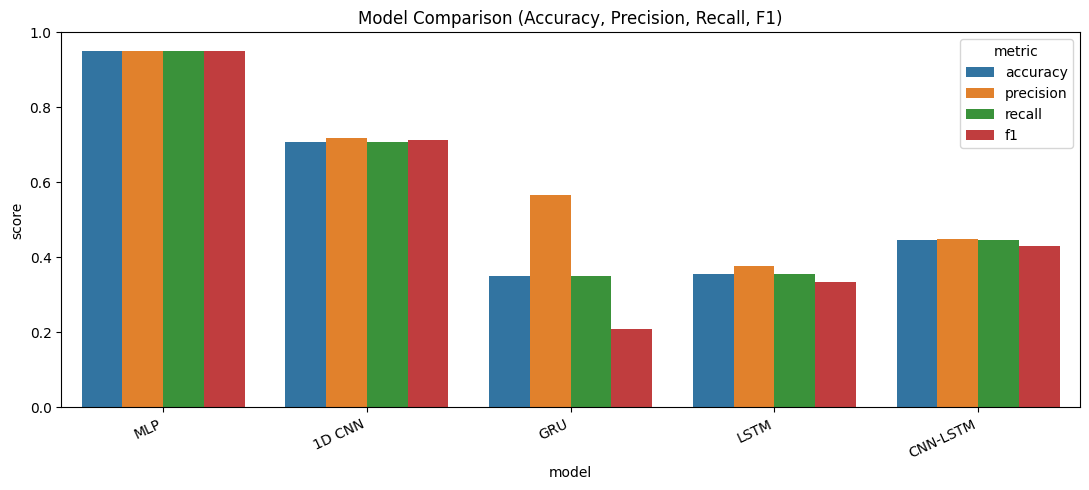

In [13]:
# ============================================================
# COMPARISON GRAPH (all 5 models in one chart)
# ============================================================
if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

model_order = ["MLP", "1D CNN", "GRU", "LSTM", "CNN-LSTM"]
metrics_df = pd.DataFrame(model_metrics).T
available = [m for m in model_order if m in metrics_df.index]
missing = [m for m in model_order if m not in metrics_df.index]
if missing:
    print(f"Missing models in metrics: {missing}. Run those model cells first.")

metrics_df = metrics_df.loc[available]

plot_df = metrics_df[["accuracy", "precision", "recall", "f1"]].reset_index().rename(columns={"index": "model"})
plot_df = plot_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="metric", loc="upper right")
plt.tight_layout()

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)
comparison_path = os.path.join(results_dir, "sustainability_model_comparison.png")
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
print(f"Saved comparison chart to: {comparison_path}")
plt.show()

## Train/Test Learning Curves + Spiral Net Accuracy View

This section adds two required visual diagnostics:
- Train vs validation accuracy trajectories for each sustainability model
- Spiral-net (radar/polar) comparison of model quality metrics, focused on accuracy prediction context

Saved train/validation curve chart to: ..\results\sustainability_train_val_curves.png


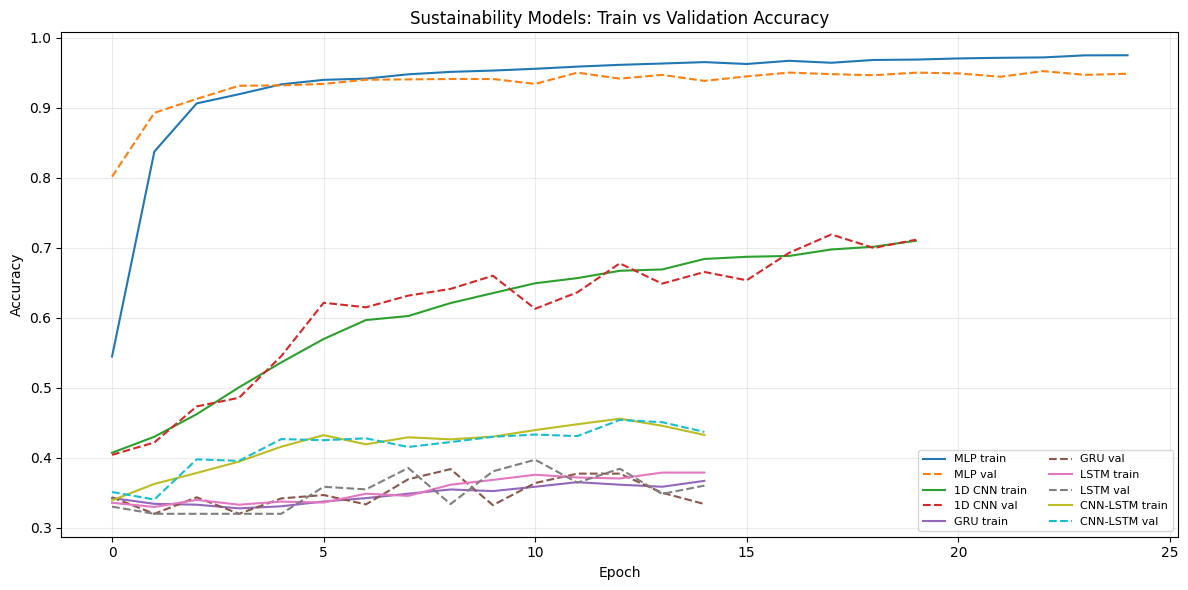

Saved spiral-net chart to: ..\results\sustainability_spiral_net_metrics.png


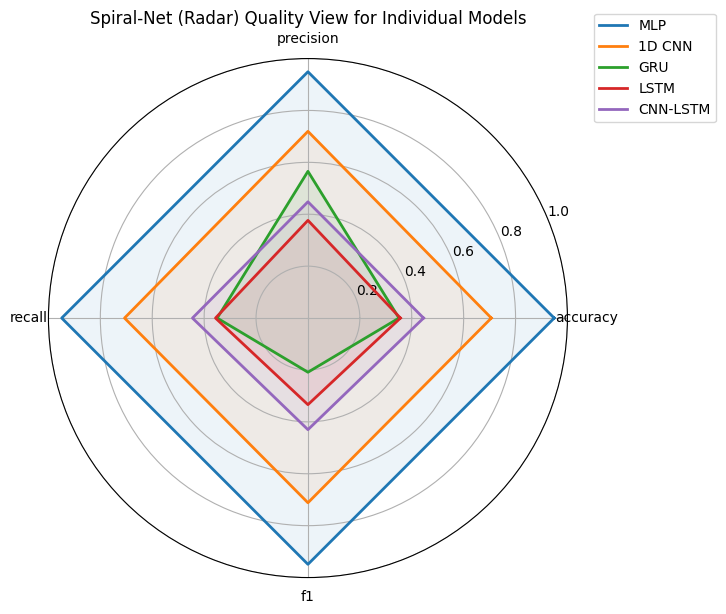

In [14]:
# ============================================================
# TRAIN vs VALIDATION CURVES + SPIRAL-NET (RADAR) METRIC VIEW
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Build learning-curve map from training histories created earlier.
history_map = {}
if "history" in globals():
    history_map["MLP"] = history
if "cnn_history" in globals():
    history_map["1D CNN"] = cnn_history
if "gru_history" in globals():
    history_map["GRU"] = gru_history
if "lstm_history" in globals():
    history_map["LSTM"] = lstm_history
if "cnn_lstm_history" in globals():
    history_map["CNN-LSTM"] = cnn_lstm_history

if history_map:
    plt.figure(figsize=(12, 6))
    for name, h in history_map.items():
        hist = h.history if hasattr(h, "history") else {}
        if "accuracy" in hist:
            plt.plot(hist["accuracy"], label=f"{name} train")
        if "val_accuracy" in hist:
            plt.plot(hist["val_accuracy"], linestyle="--", label=f"{name} val")

    plt.title("Sustainability Models: Train vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(ncol=2, fontsize=8)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    curve_path = os.path.join("..", "results", "sustainability_train_val_curves.png")
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    print(f"Saved train/validation curve chart to: {curve_path}")
    plt.show()
else:
    print("No training histories found. Run model training cells first.")

# Spiral-net (radar) comparison of model metrics
if "model_metrics" in globals() and model_metrics:
    rad_df = pd.DataFrame(model_metrics).T[["accuracy", "precision", "recall", "f1"]].copy()
    labels = rad_df.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7.5, 7.5))
    ax = plt.subplot(111, polar=True)

    for model_name, row in rad_df.iterrows():
        vals = row.values.tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=model_name)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title("Spiral-Net (Radar) Quality View for Individual Models")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()

    spiral_path = os.path.join("..", "results", "sustainability_spiral_net_metrics.png")
    plt.savefig(spiral_path, dpi=200, bbox_inches="tight")
    print(f"Saved spiral-net chart to: {spiral_path}")
    plt.show()
else:
    print("model_metrics is empty. Run training cells first.")

Saved bubble chart to: ..\results\sustainability_inference_training_ram.png


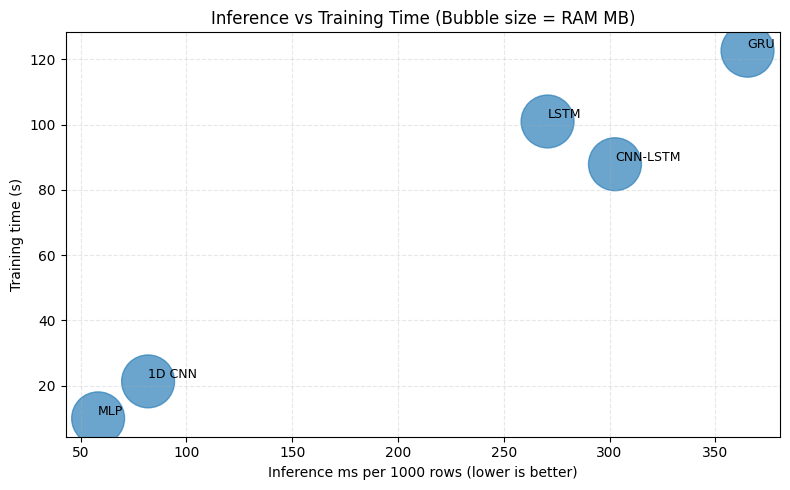

In [15]:
# ============================================================
# INFERENCE vs TRAINING TIME vs RAM (bubble chart)
# ============================================================
process = psutil.Process()

def _infer_time_ms_per_1000(model_obj, x_data):
    n = x_data.shape[0]
    if n == 0:
        return np.nan
    start = time.time()
    _ = model_obj.predict(x_data, verbose=0)
    elapsed = time.time() - start
    return (elapsed / n) * 1000 * 1000  # ms per 1000 rows

model_names = []
train_times = []
infer_ms_1k = []
ram_mb = []

# MLP
model_names.append("MLP")
train_times.append(train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(model, X_test_proc))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# 1D CNN
model_names.append("1D CNN")
train_times.append(cnn_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(cnn_model, X_test_cnn))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# GRU
model_names.append("GRU")
train_times.append(gru_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(gru_model, X_test_gru))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# LSTM
model_names.append("LSTM")
train_times.append(lstm_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(lstm_model, X_test_lstm))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# CNN-LSTM
model_names.append("CNN-LSTM")
train_times.append(cnn_lstm_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(cnn_lstm_model, X_test_cnnlstm))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

plt.figure(figsize=(8, 5))
sizes = [max(30, m) * 2 for m in ram_mb]
plt.scatter(infer_ms_1k, train_times, s=sizes, alpha=0.7, color="#2C7FB8")
for i, name in enumerate(model_names):
    plt.text(infer_ms_1k[i], train_times[i], name, fontsize=9, ha="left", va="bottom")

plt.title("Inference vs Training Time (Bubble size = RAM MB)")
plt.xlabel("Inference ms per 1000 rows (lower is better)")
plt.ylabel("Training time (s)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)
bubble_path = os.path.join(results_dir, "sustainability_inference_training_ram.png")
plt.savefig(bubble_path, dpi=200, bbox_inches="tight")
print(f"Saved bubble chart to: {bubble_path}")
plt.show()

In [16]:
# ============================================================
# SAVE METRICS + BEST MODEL SUMMARY TO RESULTS/
# ============================================================
if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)

metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values(by="accuracy", ascending=False)
metrics_path = os.path.join(results_dir, "sustainability_metrics.csv")
metrics_df.to_csv(metrics_path, index=True)
print(f"Saved metrics to: {metrics_path}")

best_model_name = metrics_df.index[0]
best_row = metrics_df.iloc[0]
best_shap_name = best_model_name.lower().replace(" ", "_").replace("-", "_")
best_shap_path = f"sustainability_shap_best_{best_shap_name}.png"
summary_lines = [
    "Sustainability Classification Results",
    "====================================",
    f"Best model: {best_model_name}",
    f"Accuracy: {best_row['accuracy']:.4f}",
    f"Precision (macro): {best_row['precision']:.4f}",
    f"Recall (macro): {best_row['recall']:.4f}",
    f"F1 (macro): {best_row['f1']:.4f}",
    "",
    "All model metrics saved in sustainability_metrics.csv",
    "Charts saved:",
    "- sustainability_model_comparison.png",
    "- sustainability_inference_training_ram.png",
    "",
    "Best-model SHAP plot:",
    f"- {best_shap_path}",
    "",
    "Model artifact:",
    "- models/sustainability_model.pkl (MLP)",
]
summary_path = os.path.join(results_dir, "sustainability_results_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))
print(f"Saved summary to: {summary_path}")

Saved metrics to: ..\results\sustainability_metrics.csv
Saved summary to: ..\results\sustainability_results_summary.txt


Best model for SHAP: MLP

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


  0%|          | 0/20 [00:00<?, ?it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step



  1/157 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


 93/157 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step


Saved SHAP plot to: ..\results\sustainability_shap_best_mlp.png


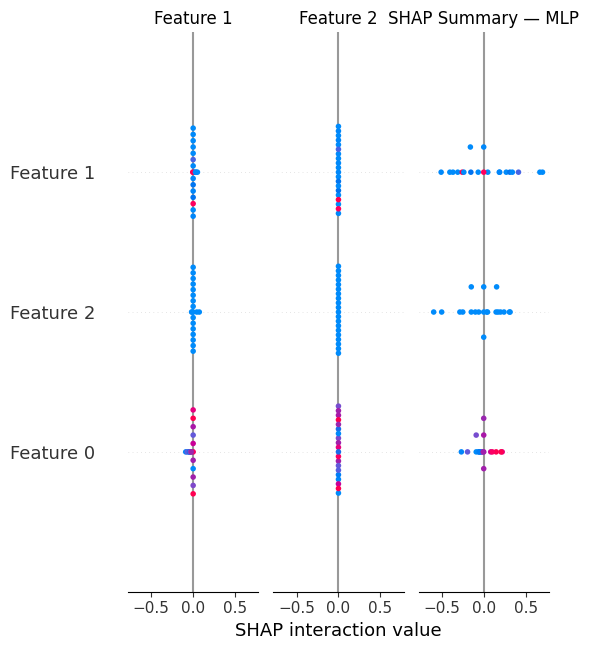

In [17]:
# ============================================================
# SHAP EXPLANATIONS FOR BEST MODEL ONLY (lightweight)
# ============================================================
def _sample_rows(array_like, n):
    n = min(n, array_like.shape[0])
    idx = np.random.choice(array_like.shape[0], n, replace=False)
    return array_like[idx]

def _shap_kernel_tabular(model_predict, background, explain, title, save_path=None):
    explainer = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(explain, nsamples=100)
    shap.summary_plot(shap_values, explain, show=False)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved SHAP plot to: {save_path}")
    plt.show()

def _make_seq_predictor(model_obj, timesteps):
    def _predict(flat_x):
        reshaped = flat_x.reshape(flat_x.shape[0], timesteps, 1)
        return model_obj.predict(reshaped, verbose=0)
    return _predict

def _flatten_3d(arr_3d):
    return arr_3d.reshape(arr_3d.shape[0], -1)

if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

metrics_df = pd.DataFrame(model_metrics).T
best_model_name = metrics_df["accuracy"].idxmax()
print(f"Best model for SHAP: {best_model_name}")

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)

# Prepare SHAP inputs based on the best model
if best_model_name == "MLP":
    bg = _sample_rows(X_train_proc, 50)
    explain = _sample_rows(X_test_proc, 20)
    predictor = model.predict
    title = "SHAP Summary — MLP"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_mlp.png")
elif best_model_name == "1D CNN":
    bg = _flatten_3d(_sample_rows(X_train_cnn, 30))
    explain = _flatten_3d(_sample_rows(X_test_cnn, 15))
    predictor = _make_seq_predictor(cnn_model, X_train_cnn.shape[1])
    title = "SHAP Summary — 1D CNN"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_1d_cnn.png")
elif best_model_name == "GRU":
    bg = _flatten_3d(_sample_rows(X_train_gru, 30))
    explain = _flatten_3d(_sample_rows(X_test_gru, 15))
    predictor = _make_seq_predictor(gru_model, X_train_gru.shape[1])
    title = "SHAP Summary — GRU"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_gru.png")
elif best_model_name == "LSTM":
    bg = _flatten_3d(_sample_rows(X_train_lstm, 30))
    explain = _flatten_3d(_sample_rows(X_test_lstm, 15))
    predictor = _make_seq_predictor(lstm_model, X_train_lstm.shape[1])
    title = "SHAP Summary — LSTM"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_lstm.png")
elif best_model_name == "CNN-LSTM":
    bg = _flatten_3d(_sample_rows(X_train_cnnlstm, 30))
    explain = _flatten_3d(_sample_rows(X_test_cnnlstm, 15))
    predictor = _make_seq_predictor(cnn_lstm_model, X_train_cnnlstm.shape[1])
    title = "SHAP Summary — CNN-LSTM"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_cnn_lstm.png")
else:
    raise ValueError(f"Unknown best model name: {best_model_name}")

_shap_kernel_tabular(predictor, bg, explain, title, shap_path)

In [18]:
# Quick metrics snapshot for audit
if 'model_metrics' in globals() and model_metrics:
    print(pd.DataFrame(model_metrics).T[['accuracy', 'precision', 'recall', 'f1']].round(4))
else:
    print('model_metrics is empty. Run training cells first.')

          accuracy  precision  recall      f1
MLP         0.9490     0.9491  0.9490  0.9490
1D CNN      0.7067     0.7195  0.7068  0.7117
GRU         0.3508     0.5654  0.3497  0.2087
LSTM        0.3563     0.3765  0.3563  0.3337
CNN-LSTM    0.4455     0.4480  0.4451  0.4301
